In [1]:
import numpy as np  
import pandas as pd 
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

# Specifically suppress the SettingWithCopyWarning (common in pandas indexing)
import pandas as pd
pd.options.mode.chained_assignment = None

BLUE_PRIMARY = '#3498db'
ORANGE_PRIMARY = '#e67e22'
BLUE_SECONDARY = '#2980b9'
ORANGE_SECONDARY = '#d35400'
PALETTE_BO = [BLUE_PRIMARY, ORANGE_PRIMARY, BLUE_SECONDARY, ORANGE_SECONDARY]

In [2]:
df = pd.read_csv("data/Final_Cleaned_Dataset.csv")
df.head()

,number,parent_incident,caller_id,short_description,u_business_service,u_category,state,assignment_group,assigned_to,sys_created_on,...,business_duration,priority,is_outlier,impact,calendar_duration,made_sla,opened at,closed at,short_description_cleaned,calc_duration_sec
0,INC0219273,STANDALONE,Pagerduty Integration,PagerDuty: jNH237-3400-00 (????????? ????) - H...,Zabbix,Performance > System Unavailable,Resolved,OIT Operations Center,Javier Villalobos,02/04/2026 06:10:00,...,0.0,P2,False,Campus Wide,1316.0,True,02/04/2026 06:10:00,02/04/2026 06:32:00,PagerDuty: Juniper Switch: Nedderman Hall Room...,1320.0
1,INC0219272,STANDALONE,Pagerduty Integration,PagerDuty: jNH237-3400-20 (????????? ????) - H...,Zabbix,Performance > System Unavailable,Resolved,OIT Operations Center,Javier Villalobos,02/04/2026 05:39:00,...,0.0,P2,False,Campus Wide,3176.0,True,02/04/2026 05:39:00,02/04/2026 06:32:00,PagerDuty: Juniper Switch: Nedderman Hall Room...,3180.0
2,INC0219271,STANDALONE,Pagerduty Integration,PagerDuty: jNH237-3400-10 (????????? ????) - H...,Zabbix,Performance > System Unavailable,Resolved,OIT Operations Center,Javier Villalobos,02/04/2026 05:39:00,...,0.0,P2,False,Campus Wide,3240.0,True,02/04/2026 05:39:00,02/04/2026 06:33:00,PagerDuty: Juniper Switch: Nedderman Hall Room...,3240.0
3,INC0219270,STANDALONE,Pagerduty Integration,PagerDuty: jNH127-3400-00 (????????? ????) - H...,Zabbix,Performance > System Unavailable,Resolved,OIT Operations Center,Javier Villalobos,02/04/2026 05:31:00,...,0.0,P2,False,Campus Wide,3659.0,True,02/04/2026 05:31:00,02/04/2026 06:32:00,PagerDuty: Juniper Switch: Nedderman Hall Room...,3660.0
4,INC0219269,STANDALONE,Pagerduty Integration,PagerDuty: jNH127-4100-00 (????????? ????) (48...,Zabbix,Performance > System Unavailable,Resolved,OIT Operations Center,Javier Villalobos,02/04/2026 05:28:00,...,0.0,P2,False,Campus Wide,3599.0,True,02/04/2026 05:28:00,02/04/2026 06:28:00,PagerDuty: Juniper Switch: Nedderman Hall Room...,3600.0


In [3]:
# Filter for P1 incidents only
p1_df = df[df['priority'] == 'P1']

# Filter out Logic App rows from P1 only
p1_filtered_df = p1_df[~p1_df['short_description_cleaned'].str.contains('logic.?app', case=False, na=False, regex=True)]

# Top 3 BEFORE removal (P1 only)
top3_before = p1_df['assigned_to'].value_counts().head(3).reset_index()
top3_before.columns = ['assigned_to', 'incident_count']

# Top 3 AFTER removal (P1 only)
top3_after = p1_filtered_df['assigned_to'].value_counts().head(3).reset_index()
top3_after.columns = ['assigned_to', 'incident_count']

# Print both
print(f"Total P1 incidents: {len(p1_df)}")
print(f"P1 after Logic App removal: {len(p1_filtered_df)}\n")

print("Top 3 Assignees (P1) — BEFORE Logic App Removal:\n")
for i, row in top3_before.iterrows():
    print(f"  #{i+1}  {row['assigned_to']} — {row['incident_count']} incidents")

print("\nTop 3 Assignees (P1) — AFTER Logic App Removal:\n")
for i, row in top3_after.iterrows():
    print(f"  #{i+1}  {row['assigned_to']} — {row['incident_count']} incidents")


Total P1 incidents: 585
P1 after Logic App removal: 582

Top 3 Assignees (P1) — BEFORE Logic App Removal:

  #1  Chee-Ming Chew — 268 incidents
  #2  Brandon Bunger — 126 incidents
  #3  Kameron Ingrando — 52 incidents

Top 3 Assignees (P1) — AFTER Logic App Removal:

  #1  Chee-Ming Chew — 268 incidents
  #2  Brandon Bunger — 126 incidents
  #3  Kameron Ingrando — 52 incidents


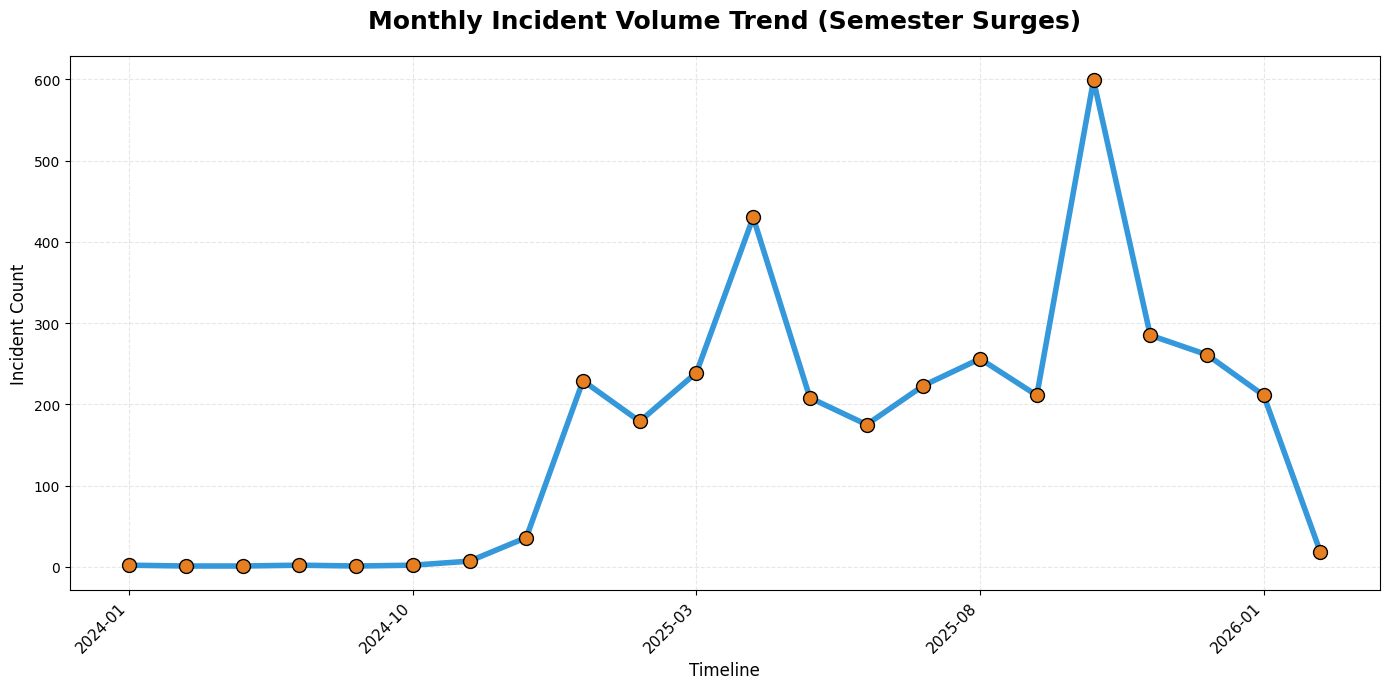

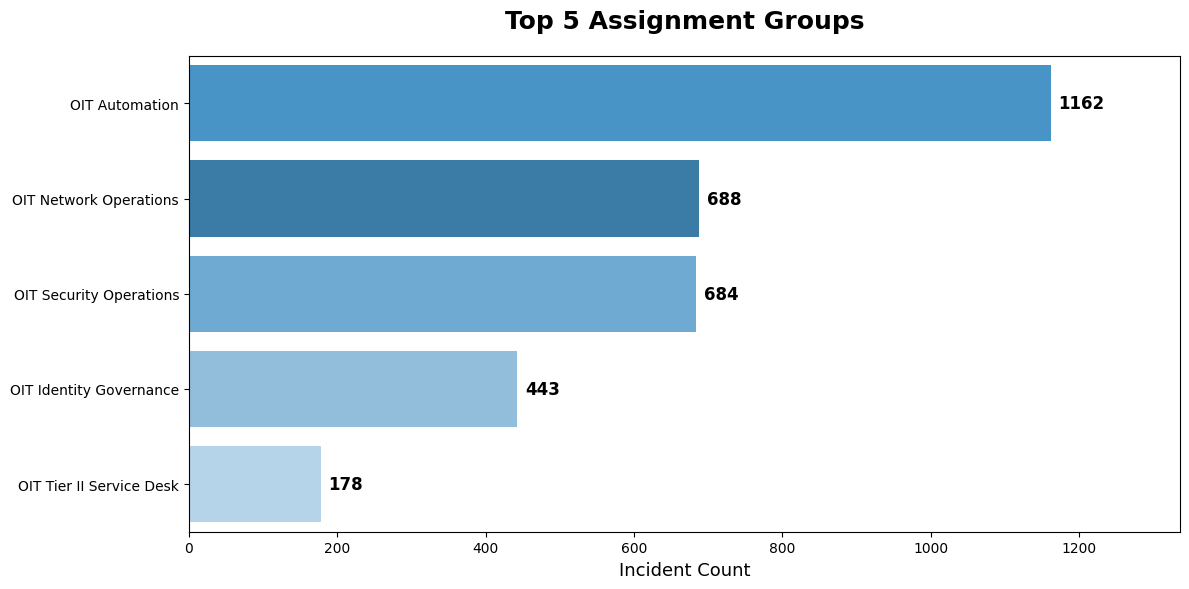

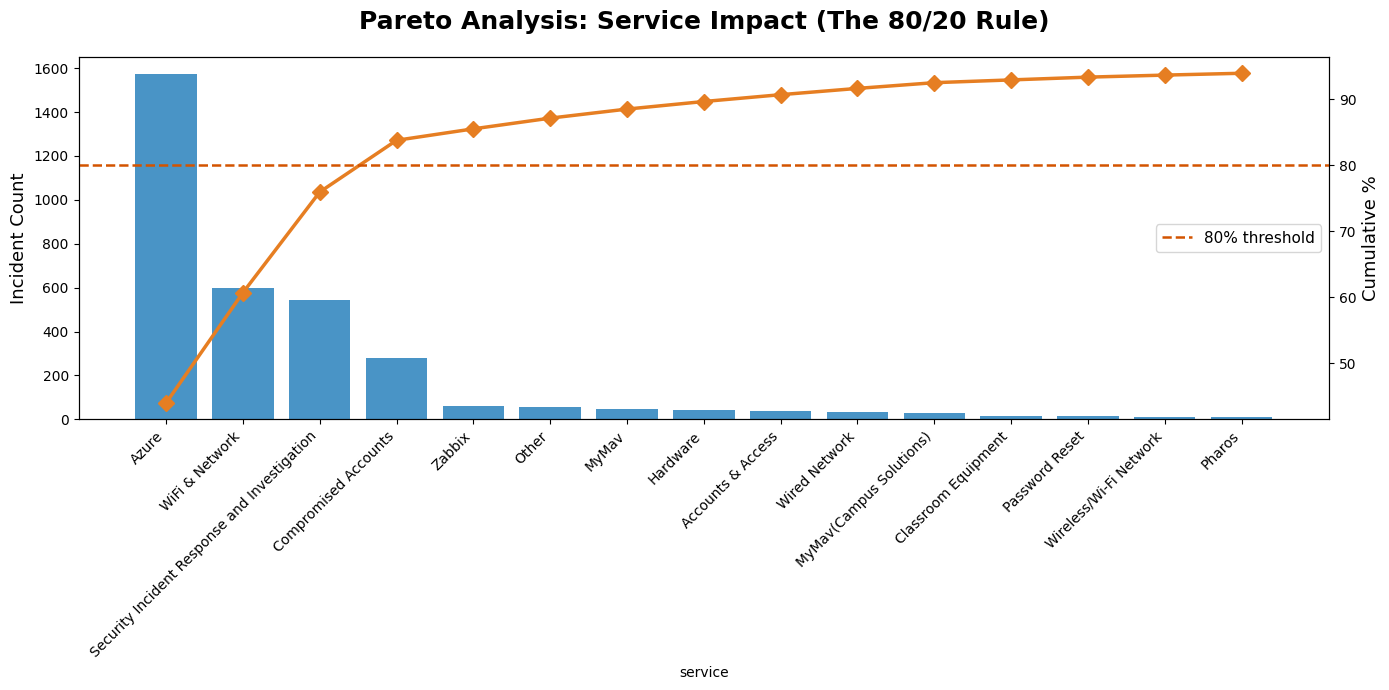

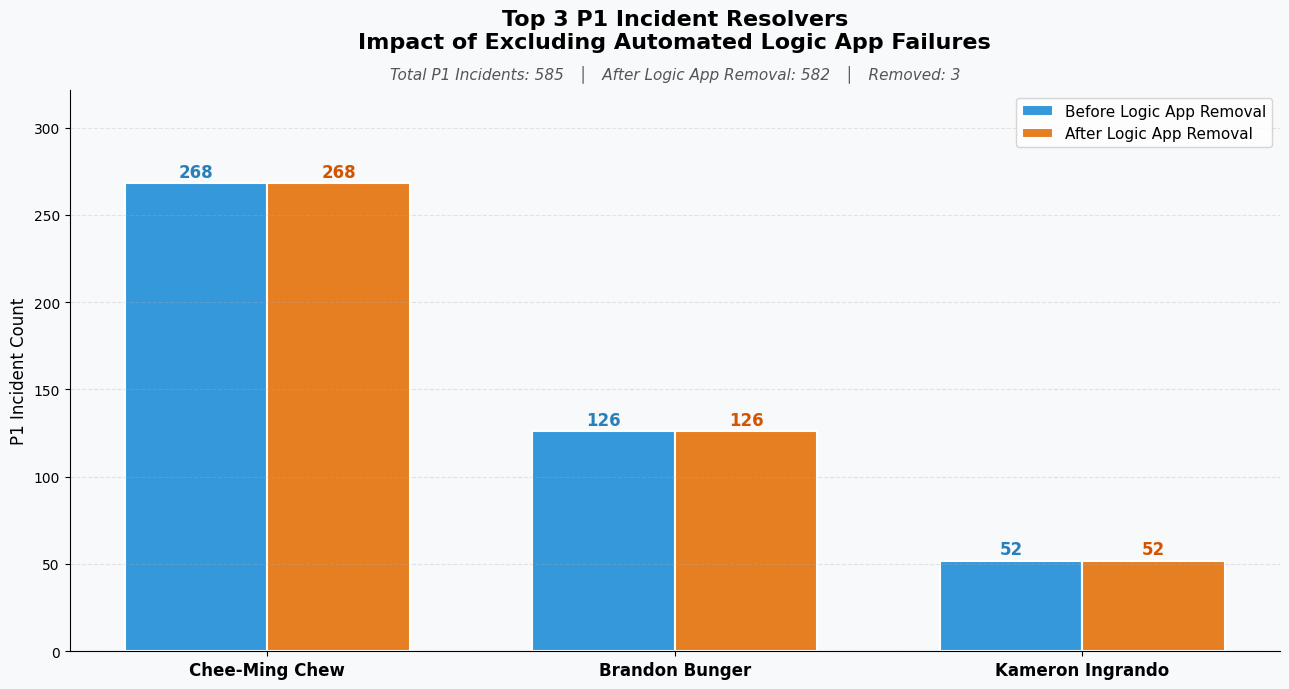

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ── Color Palette ──────────────────────────────────────────────
BLUE_PRIMARY     = '#3498db'
ORANGE_PRIMARY   = '#e67e22'
BLUE_SECONDARY   = '#2980b9'
ORANGE_SECONDARY = '#d35400'
PALETTE_BO = [BLUE_PRIMARY, ORANGE_PRIMARY, BLUE_SECONDARY, ORANGE_SECONDARY]

# ── Pre-processing ─────────────────────────────────────────────
df['opened at'] = pd.to_datetime(df['opened at'], errors='coerce')
df['month_year'] = df['opened at'].dt.to_period('M').astype(str)

# ══════════════════════════════════════════════════════════════
# CHART 1: Monthly Incident Volume Trend
# ══════════════════════════════════════════════════════════════
monthly_counts = df.groupby('month_year').size()

plt.figure(figsize=(14, 7))
monthly_counts.plot(
    kind='line',
    marker='o',
    color=BLUE_PRIMARY,
    linewidth=4,
    markersize=10,
    markerfacecolor=ORANGE_PRIMARY,
    markeredgecolor='black'
)
plt.title('Monthly Incident Volume Trend (Semester Surges)', fontsize=18, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylabel('Incident Count', fontsize=12)
plt.xlabel('Timeline', fontsize=12)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# CHART 2: Top 5 Assignment Groups
# ══════════════════════════════════════════════════════════════
top_groups = df['assignment_group'].value_counts().head(5)
bar_colors = [BLUE_PRIMARY, BLUE_SECONDARY, '#5dade2', '#85c1e9', '#aed6f1']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_groups.values, y=top_groups.index, ax=ax, palette=bar_colors)

for patch in ax.patches:
    width = patch.get_width()
    ax.text(
        width + 10,
        patch.get_y() + patch.get_height() / 2,
        f'{int(width)}',
        va='center', ha='left',
        fontsize=12, fontweight='bold'
    )

ax.set_xlim(0, top_groups.values.max() * 1.15)
ax.set_title('Top 5 Assignment Groups', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Incident Count', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# CHART 3: Pareto Analysis
# ══════════════════════════════════════════════════════════════
service_counts = df['u_business_service'].value_counts().reset_index()
service_counts.columns = ['service', 'count']
service_counts['cum_percent'] = 100 * (service_counts['count'].cumsum() / service_counts['count'].sum())

fig, ax_p = plt.subplots(figsize=(14, 7))
sns.barplot(x=service_counts['service'].head(15), y=service_counts['count'].head(15),
            ax=ax_p, color=BLUE_PRIMARY)

ax_p2 = ax_p.twinx()
ax_p2.plot(service_counts['service'].head(15), service_counts['cum_percent'].head(15),
           color=ORANGE_PRIMARY, marker='D', linewidth=2.5, markersize=8)
ax_p2.axhline(80, color=ORANGE_SECONDARY, linestyle='--', linewidth=1.8, label='80% threshold')

ax_p.set_xticklabels(service_counts['service'].head(15), rotation=45, ha='right')
ax_p.set_title('Pareto Analysis: Service Impact (The 80/20 Rule)', fontsize=18, fontweight='bold', pad=20)
ax_p.set_ylabel('Incident Count', fontsize=13)
ax_p2.set_ylabel('Cumulative %', fontsize=13)
ax_p2.legend(loc='center right', fontsize=11)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# CHART 4: Top 3 P1 Resolvers — Before vs. After Logic App Removal
# ══════════════════════════════════════════════════════════════
p1_df          = df[df['priority'] == 'P1']
p1_filtered_df = p1_df[~p1_df['short_description_cleaned'].str.contains('logic.?app', case=False, na=False, regex=True)]

top3_before = p1_df['assigned_to'].value_counts().head(3).reset_index()
top3_before.columns = ['assigned_to', 'count']

top3_after = p1_filtered_df['assigned_to'].value_counts().head(3).reset_index()
top3_after.columns = ['assigned_to', 'count']

names       = top3_before['assigned_to'].tolist()
before_vals = top3_before['count'].tolist()
after_vals  = [
    top3_after.loc[top3_after['assigned_to'] == n, 'count'].values[0]
    if n in top3_after['assigned_to'].values else 0
    for n in names
]

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

bars1 = ax.bar(x - width/2, before_vals, width, color=BLUE_PRIMARY,
               edgecolor='white', linewidth=1.5, label='Before Logic App Removal')
bars2 = ax.bar(x + width/2, after_vals,  width, color=ORANGE_PRIMARY,
               edgecolor='white', linewidth=1.5, label='After Logic App Removal')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{int(bar.get_height())}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=BLUE_SECONDARY)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{int(bar.get_height())}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=ORANGE_SECONDARY)

total_before = len(p1_df)
total_after  = len(p1_filtered_df)
removed      = total_before - total_after
ax.annotate(
    f'Total P1 Incidents: {total_before}   │   After Logic App Removal: {total_after}   │   Removed: {removed}',
    xy=(0.5, 1.02), xycoords='axes fraction', ha='center', fontsize=11,
    color='#555555', style='italic'
)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12, fontweight='bold')
ax.set_ylabel('P1 Incident Count', fontsize=12)
ax.set_title('Top 3 P1 Incident Resolvers\nImpact of Excluding Automated Logic App Failures',
             fontsize=16, fontweight='bold', pad=30)
ax.set_ylim(0, max(before_vals) * 1.2)
ax.legend(fontsize=11, framealpha=0.8)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [5]:
# import sys
# !{sys.executable} -m pip install statsmodels


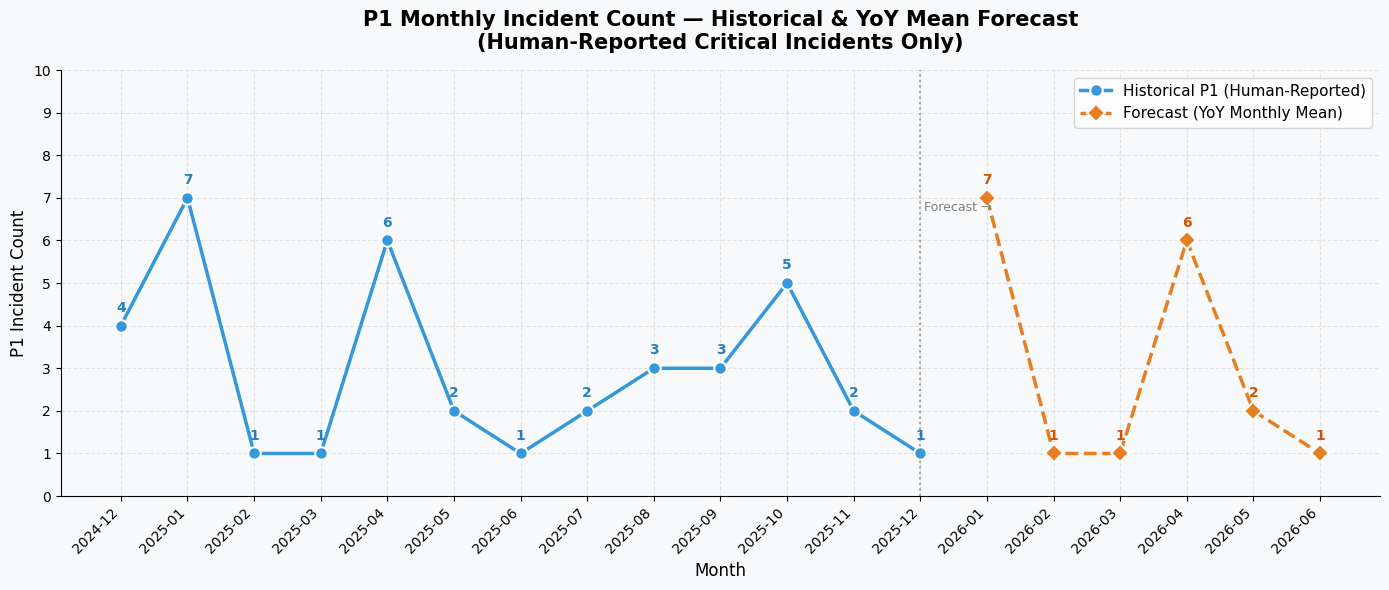

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Color Palette ──────────────────────────────────────────────
BLUE_PRIMARY     = '#3498db'
ORANGE_PRIMARY   = '#e67e22'
BLUE_SECONDARY   = '#2980b9'
ORANGE_SECONDARY = '#d35400'

# --- DATA PREP ---
df = pd.read_csv('data/Final_Cleaned_Dataset.csv')
df['opened at'] = pd.to_datetime(df['opened at'], errors='coerce')
df = df.dropna(subset=['opened at'])
df['month_year'] = df['opened at'].dt.to_period('M').astype(str)
df['month_num']  = df['opened at'].dt.month

# Filter to true P1s (exclude automated monitoring alerts)
AUTOMATED = r'pagerduty|logic.?app|zabbix|monitoring|integration|automated|switch.*down|is down'
p1_human = df[
    (df['priority'] == 'P1') &
    (~df['short_description_cleaned'].str.contains(AUTOMATED, case=False, na=False, regex=True))
]

# Monthly counts
p1_monthly = p1_human['month_year'].value_counts().sort_index()

# YoY Mean Forecast (next 6 months)
p1_human_copy = p1_human.copy()
month_mean = p1_human_copy.groupby('month_num').size().div(
    p1_human_copy.groupby('month_num')['month_year'].nunique()
).round().astype(int)

last_period    = pd.Period(p1_monthly.index[-1], freq='M')
future_periods = [last_period + i for i in range(1, 7)]
forecast_vals  = [int(month_mean.get(p.month, p1_monthly.median())) for p in future_periods]
forecast_index = [str(p) for p in future_periods]

# --- PLOT ---
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

ax.plot(p1_monthly.index, p1_monthly.values,
        marker='o', color=BLUE_PRIMARY, linewidth=2.5,
        markersize=9, markeredgecolor='white', markeredgewidth=1.5,
        label='Historical P1 (Human-Reported)')

ax.plot(forecast_index, forecast_vals,
        marker='D', color=ORANGE_PRIMARY, linewidth=2.5,
        linestyle='--', markersize=9, markeredgecolor='white', markeredgewidth=1.5,
        label='Forecast (YoY Monthly Mean)')

# Annotate every point with its value
for x, y in zip(p1_monthly.index, p1_monthly.values):
    ax.annotate(str(y), (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold', color=BLUE_SECONDARY)

for x, y in zip(forecast_index, forecast_vals):
    ax.annotate(str(y), (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold', color=ORANGE_SECONDARY)

# Divider between history and forecast
ax.axvline(x=p1_monthly.index[-1], color='grey', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(p1_monthly.index[-1], ax.get_ylim()[1] * 0.95, ' Forecast →',
        fontsize=9, color='grey', va='top')

ax.set_ylim(0, 10)                          # ← Y-axis capped at 10
ax.set_yticks(range(0, 11))                 # ← Whole number ticks 0–10
ax.set_title('P1 Monthly Incident Count — Historical & YoY Mean Forecast\n'
             '(Human-Reported Critical Incidents Only)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('P1 Incident Count', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


── P1 Incident Count by Month & Source ──
source      Automated (Monitoring)  Human-Reported  Total
month_year                                               
2024-12                          0               4      4
2025-01                          5               7     12
2025-02                          2               1      3
2025-03                         28               1     29
2025-04                         45               6     51
2025-05                         28               2     30
2025-06                          5               1      6
2025-07                         13               2     15
2025-08                         19               3     22
2025-09                         19               3     22
2025-10                        382               5    387
2025-11                          1               2      3
2025-12                          0               1      1


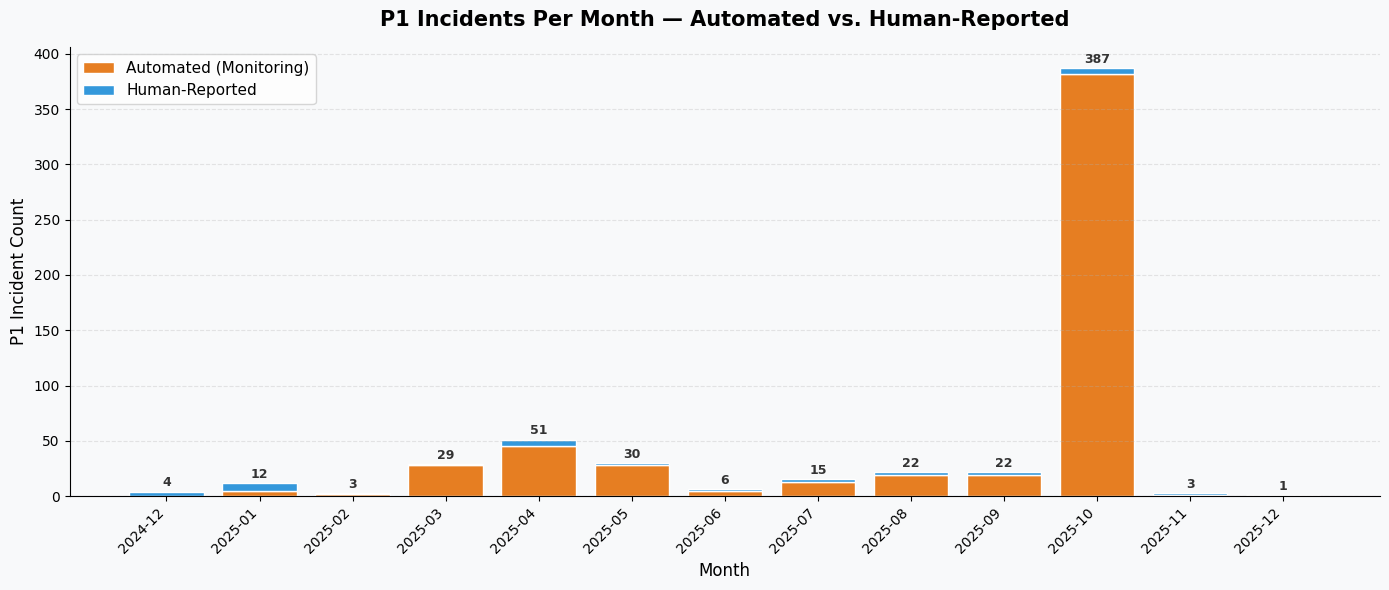

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Color Palette ──────────────────────────────────────────────
BLUE_PRIMARY     = '#3498db'
ORANGE_PRIMARY   = '#e67e22'
BLUE_SECONDARY   = '#2980b9'
ORANGE_SECONDARY = '#d35400'

# --- DATA PREP ---
df = pd.read_csv('data/Final_Cleaned_Dataset.csv')
df['opened at'] = pd.to_datetime(df['opened at'], errors='coerce')
df = df.dropna(subset=['opened at'])
df['month_year'] = df['opened at'].dt.to_period('M').astype(str)

p1 = df[df['priority'] == 'P1'].copy()

# Tag each row as Automated or Human-Reported
AUTOMATED = r'pagerduty|logic.?app|zabbix|monitoring|integration|automated|switch.*down|is down'
p1['source'] = p1['short_description_cleaned'].str.contains(
    AUTOMATED, case=False, na=False, regex=True
).map({True: 'Automated (Monitoring)', False: 'Human-Reported'})

# Monthly counts by source
monthly = p1.groupby(['month_year', 'source']).size().unstack(fill_value=0)

# Print raw table for reference
print("── P1 Incident Count by Month & Source ──")
monthly['Total'] = monthly.sum(axis=1)
print(monthly.to_string())
monthly = monthly.drop(columns='Total')  # remove before plotting

# --- STACKED BAR CHART ---
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

# Plot stacked bars
if 'Automated (Monitoring)' in monthly.columns:
    ax.bar(monthly.index, monthly['Automated (Monitoring)'],
           color=ORANGE_PRIMARY, label='Automated (Monitoring)', edgecolor='white')

if 'Human-Reported' in monthly.columns:
    bottom = monthly.get('Automated (Monitoring)', pd.Series(0, index=monthly.index))
    ax.bar(monthly.index, monthly['Human-Reported'],
           bottom=bottom, color=BLUE_PRIMARY, label='Human-Reported', edgecolor='white')

# Total label on top of each bar
totals = monthly.sum(axis=1)
for i, (month, total) in enumerate(totals.items()):
    ax.text(i, total + 2, str(int(total)),
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

ax.set_title('P1 Incidents Per Month — Automated vs. Human-Reported',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('P1 Incident Count', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_xticks(range(len(monthly.index)))
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()



Analyzing P1
P1 human-reported incidents used: 38
Note: 51 weeks — using Monthly analysis.


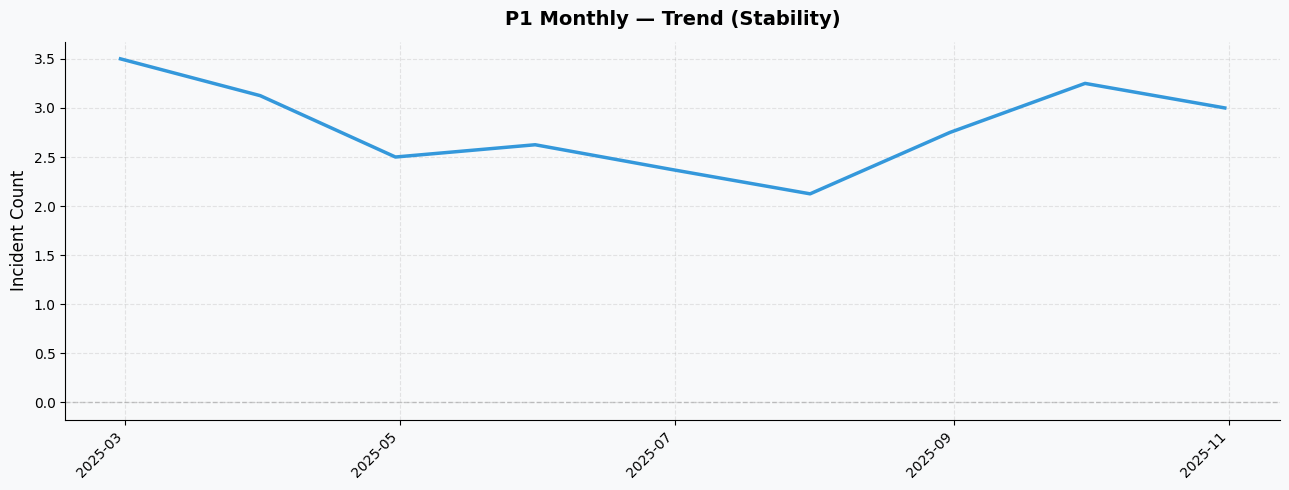

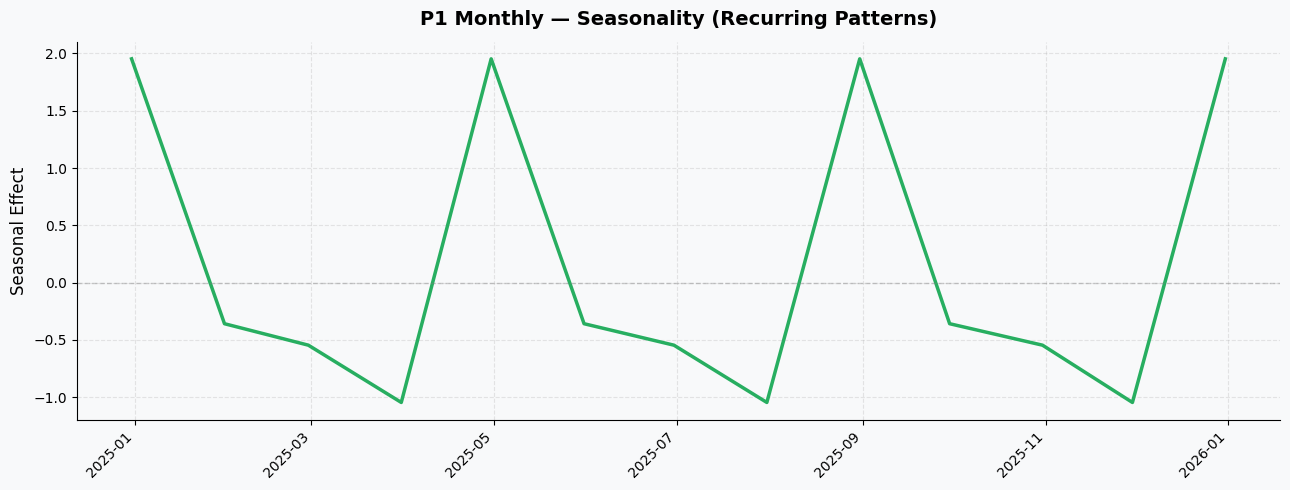

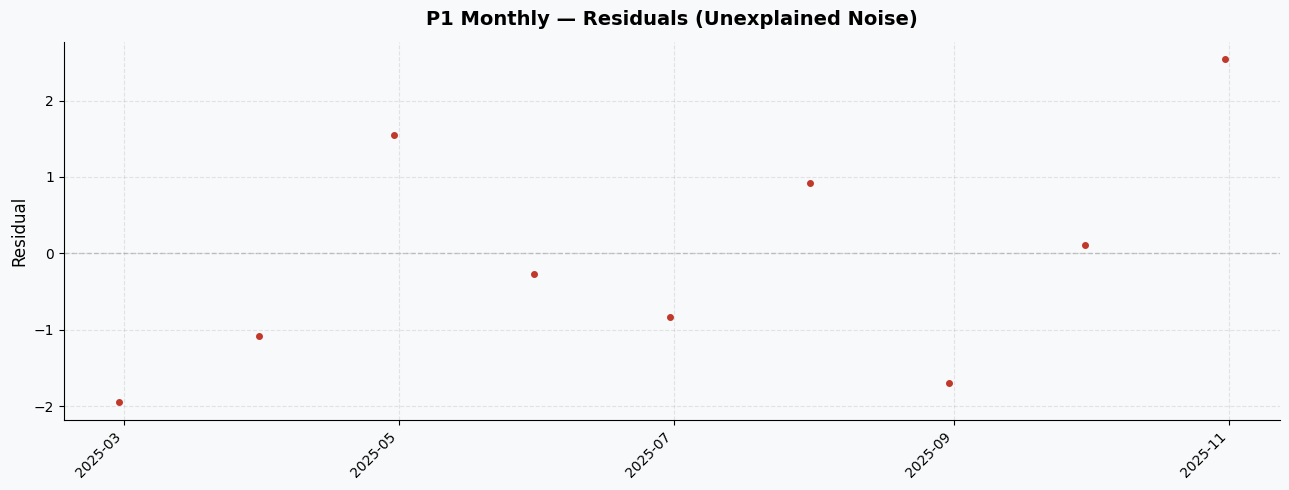

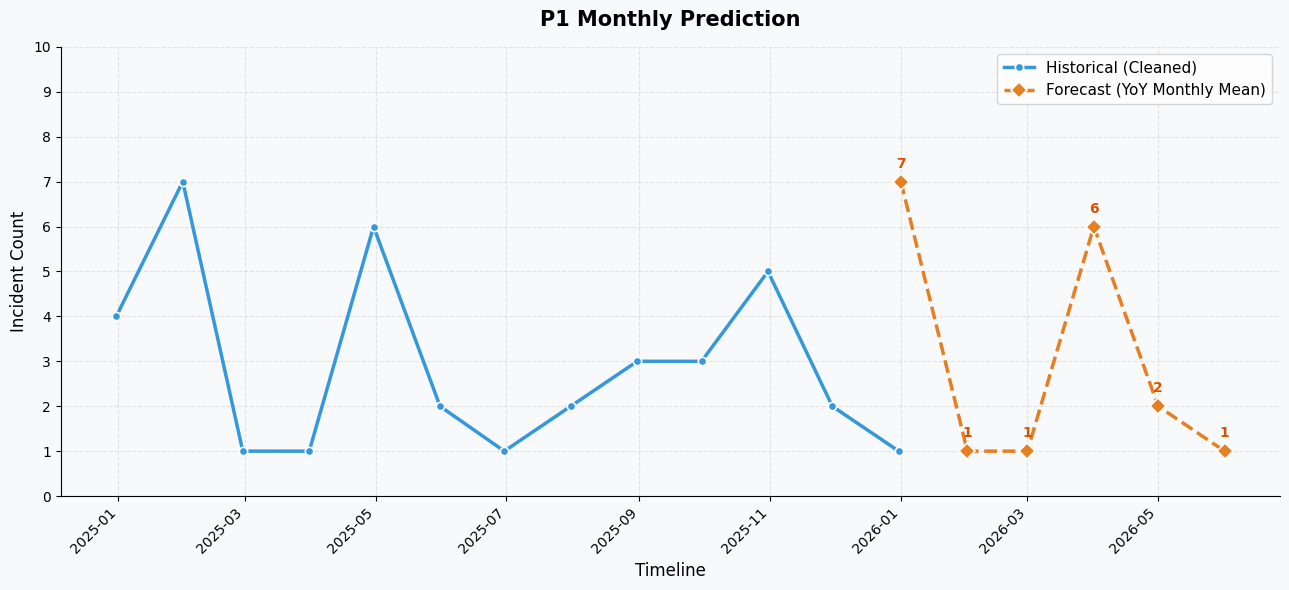


Analyzing P2
[P2] Outliers capped at median (30):
   • 2025-04-13 00:00:00 → 161  →  30


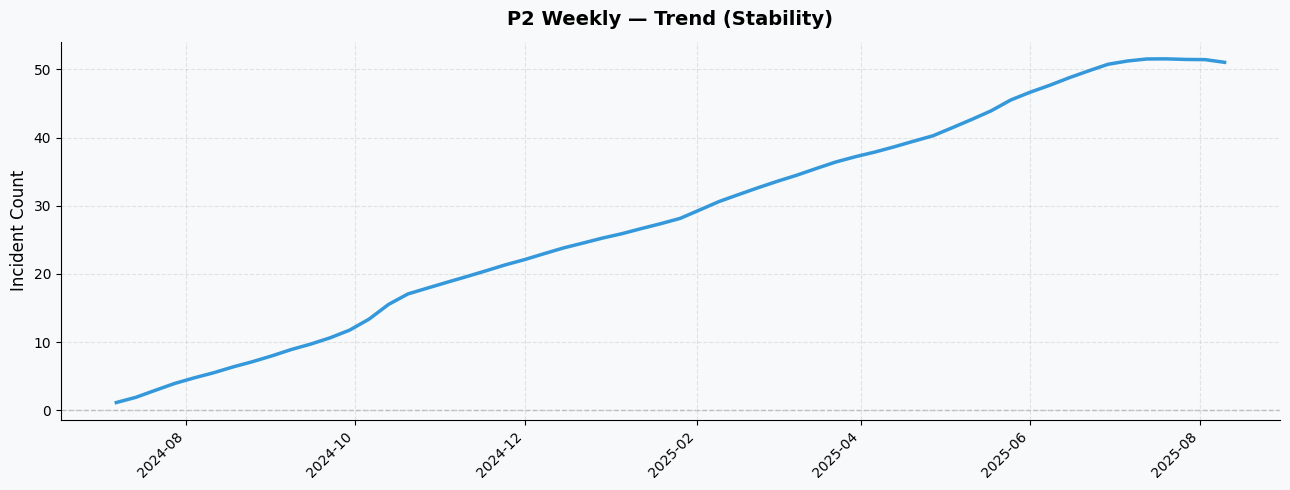

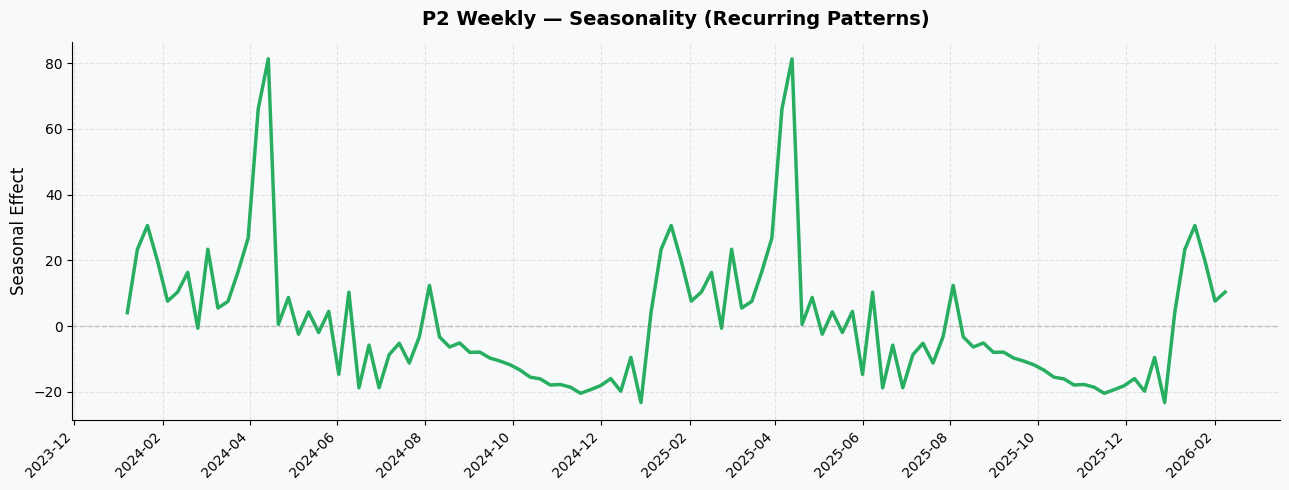

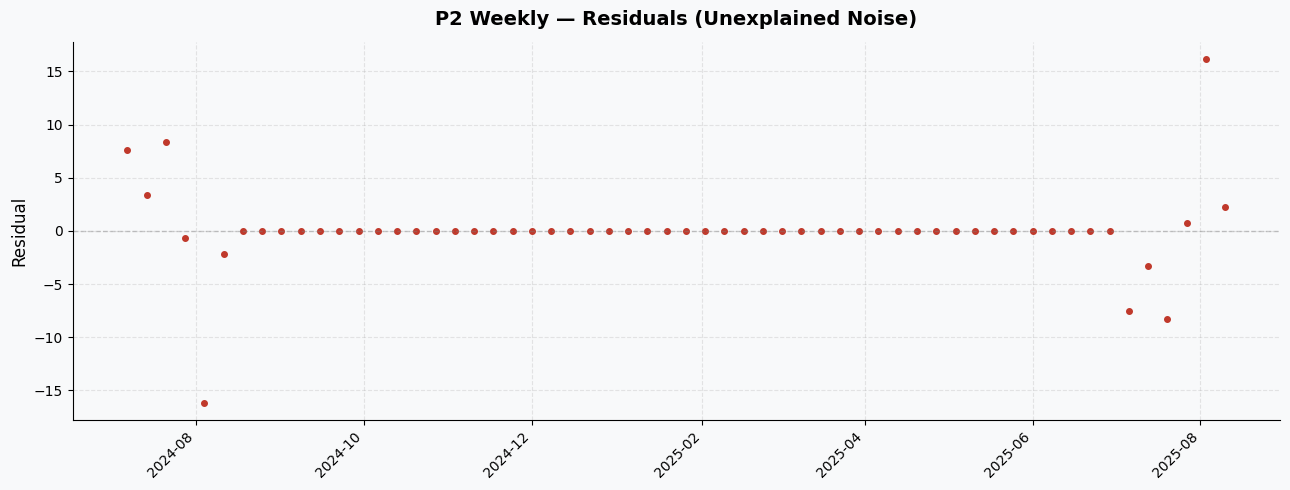

c:\Users\anuva\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


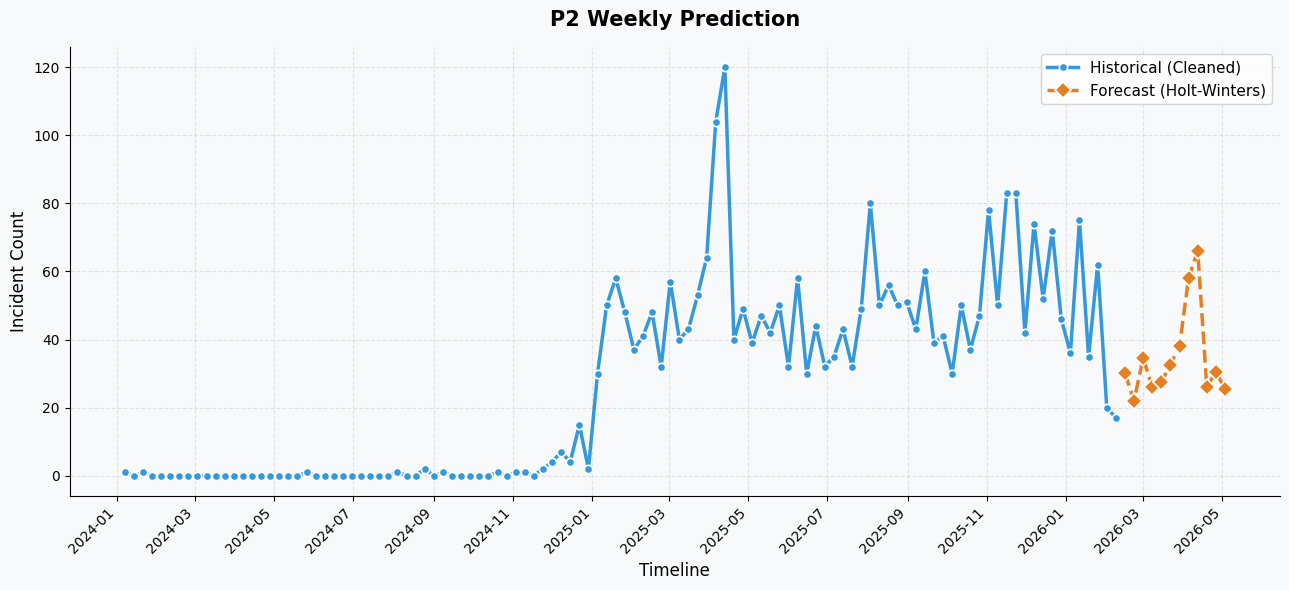

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import os
VIZ_DIR = 'Visualizations'
os.makedirs(VIZ_DIR, exist_ok=True)


# ── Color Palette ──────────────────────────────────────────────
BLUE_PRIMARY     = '#3498db'
ORANGE_PRIMARY   = '#e67e22'
BLUE_SECONDARY   = '#2980b9'
ORANGE_SECONDARY = '#d35400'

AUTOMATED = r'pagerduty|logic.?app|zabbix|monitoring|integration|automated|switch.*down|is down'

# --- 1. DATA PREPARATION ---
df = pd.read_csv('data/Final_Cleaned_Dataset.csv')
df['opened at'] = pd.to_datetime(df['opened at'], errors='coerce')
df = df.dropna(subset=['opened at'])

buildings = ['Nedderman Hall', 'Wolf Hall', 'Life Science', 'University Hall',
             'Pickard Hall', 'ERB', 'COBA', 'Davis Hall']
issue_map = {
    'Network/Wi-Fi': ['wifi', 'network', 'switch', 'router', 'connection', 'internet'],
    'Cloud/Server':  ['azure', 'server', 'host', 'vm', 'database', 'zabbix'],
    'Security/Account': ['login', 'account', 'access', 'password', 'compromised', 'mfa']
}

def extract_metadata(row):
    text  = str(row['short_description_cleaned']).lower()
    bldg  = next((b for b in buildings if b.lower() in text), 'Campus Wide/Other')
    issue = 'General Technical'
    for cat, terms in issue_map.items():
        if any(t in text for t in terms): issue = cat; break
    return pd.Series([bldg, issue])

df[['building', 'issue_type']] = df.apply(extract_metadata, axis=1)


# --- 2. OUTLIER REMOVAL ---
def remove_outliers_iqr(series, label=''):
    Q1, Q3  = series.quantile(0.25), series.quantile(0.75)
    IQR     = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    median  = series.median()
    outliers = series[(series < lower) | (series > upper)]
    if not outliers.empty:
        print(f"[{label}] Outliers capped at median ({median:.0f}):")
        for idx, val in outliers.items():
            print(f"   • {idx} → {val:.0f}  →  {median:.0f}")
    return series.clip(lower=lower, upper=upper).fillna(median)


# --- 3. DECOMPOSITION: 3 SEPARATE CHARTS ---
def plot_decomposition(decomp, p_level, freq_label):
    bg       = '#f8f9fa'
    locator  = mdates.MonthLocator(interval=2)
    formatter = mdates.DateFormatter('%Y-%m')

    def to_dt(idx):
        return idx.to_timestamp() if hasattr(idx, 'to_timestamp') else pd.to_datetime(idx)

    charts = [
        (decomp.trend,    BLUE_PRIMARY,  'Trend (Stability)',          'Incident Count',  f'{p_level.lower()}_trend.png'),
        (decomp.seasonal, '#27ae60',     'Seasonality (Recurring Patterns)', 'Seasonal Effect', f'{p_level.lower()}_seasonality.png'),
        (decomp.resid,    '#c0392b',     'Residuals (Unexplained Noise)', 'Residual',       f'{p_level.lower()}_residuals.png'),
    ]

    for series, color, subtitle, ylabel, fname in charts:
        fig, ax = plt.subplots(figsize=(13, 5))
        fig.patch.set_facecolor(bg); ax.set_facecolor(bg)
        dt_idx = to_dt(series.index)
        if subtitle.startswith('Residuals'):
            ax.plot(dt_idx, series.values, '.', color=color, markersize=8)
        else:
            ax.plot(dt_idx, series.values, color=color, linewidth=2.5)
        ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.4)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        ax.set_title(f'{p_level} {freq_label} — {subtitle}', fontsize=14, fontweight='bold', pad=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines[['top', 'right']].set_visible(False)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_DIR, fname), bbox_inches='tight')
        plt.show()


# --- 4. MAIN ANALYSIS FUNCTION ---
def analyze_priority(p_level):
    print(f"\n{'='*50}\nAnalyzing {p_level}\n{'='*50}")

    if p_level == 'P1':
        subset = df[
            (df['priority'] == 'P1') &
            (~df['short_description_cleaned'].str.contains(AUTOMATED, case=False, na=False, regex=True))
        ]
        print(f"P1 human-reported incidents used: {len(subset):,}")
    else:
        subset = df[df['priority'] == p_level]

    data_subset   = subset.set_index('opened at')
    weekly_series = data_subset.resample('W').size().fillna(0)

    if len(weekly_series) >= 104:
        period, raw_series, freq_label = 52, weekly_series, "Weekly"
    else:
        raw_series  = data_subset.resample('ME').size().fillna(0)   # 'ME' fixes deprecation
        period, freq_label = 4, "Monthly"
        print(f"Note: {len(weekly_series)} weeks — using Monthly analysis.")

    model_series = remove_outliers_iqr(raw_series, label=p_level)

    # Decomposition → 3 separate charts
    decomp = seasonal_decompose(model_series, model='additive', period=period)
    plot_decomposition(decomp, p_level, freq_label)

    # Convert index to DatetimeIndex for clean x-axis
    def to_dt(idx):
        return idx.to_timestamp() if hasattr(idx, 'to_timestamp') else pd.to_datetime(idx)

    hist_dt = to_dt(model_series.index)

    # Forecast
    if p_level == 'P1':
        s2 = subset.copy()
        s2['month_num']  = s2['opened at'].dt.month
        s2['month_year'] = s2['opened at'].dt.to_period('M').astype(str)
        month_mean = s2.groupby('month_num').size().div(
            s2.groupby('month_num')['month_year'].nunique()
        ).round().astype(int)

        last_period    = pd.Period(model_series.index[-1].strftime('%Y-%m'), freq='M')
        future_periods = [last_period + i for i in range(1, 7)]
        forecast_vals  = [int(month_mean.get(p.month, int(model_series.median()))) for p in future_periods]
        forecast_dt    = pd.to_datetime([str(p) for p in future_periods])
        forecast_label = 'Forecast (YoY Monthly Mean)'
    else:
        hw = ExponentialSmoothing(
            model_series, trend='add', seasonal='add',
            seasonal_periods=period, initialization_method="estimated"
        ).fit()
        fc_raw        = hw.forecast(6 if freq_label == "Monthly" else 12)
        forecast_vals = fc_raw.values.tolist()
        forecast_dt   = to_dt(fc_raw.index)
        forecast_label = 'Forecast (Holt-Winters)'

    # Forecast chart
    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor('#f8f9fa'); ax.set_facecolor('#f8f9fa')

    ax.plot(hist_dt, model_series.values,
            marker='o', color=BLUE_PRIMARY, linewidth=2.5, markersize=6,
            markeredgecolor='white', markeredgewidth=1.2, label='Historical (Cleaned)')
    ax.plot(forecast_dt, forecast_vals,
            marker='D', color=ORANGE_PRIMARY, linewidth=2.5, linestyle='--',
            markersize=8, markeredgecolor='white', markeredgewidth=1.2, label=forecast_label)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    if p_level == 'P1':
        ax.set_ylim(0, 10)
        ax.set_yticks(range(0, 11))
        for x, y in zip(forecast_dt, forecast_vals):
            ax.annotate(str(y), (x, y), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=10,
                        fontweight='bold', color=ORANGE_SECONDARY)

    ax.set_title(f'{p_level} {freq_label} Prediction', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('Incident Count', fontsize=12)
    ax.set_xlabel('Timeline', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, f'{p_level.lower()}_forecast.png'), bbox_inches='tight')
    plt.show()

    return model_series


# --- 5. EXECUTE ---
p1_data = analyze_priority('P1')
p2_data = analyze_priority('P2')

In [19]:
import pandas as pd
import plotly.graph_objects as go

# ── CONFIG ──────────────────────────────────────────────────────
MAIN_FILE     = "data/BldgIDsDataset.csv"
BUILDING_FILE = "data/Building IDs.xlsx"
REGION_COL    = "Campus Region"
PRIORITY_COL  = "priority"
DESC_COL      = "short_description_cleaned"
ORIG_DESC_COL = "short_description"
NUMBER_COL    = "number"
ASSIGNED_COL  = "assigned_to"
OPENED_COL    = "opened at"
CLOSED_COL    = "closed at"
LOGIC_PATTERNS = ["PAGERDUTY", "LOGIC APP", "FAILED LOGIC APP", "FAILED LOGIC", "LOGIC FAILURE"]

# ── LOAD & CLEAN ─────────────────────────────────────────────────
df   = pd.read_csv(MAIN_FILE, encoding="latin1")
bldg = pd.read_excel(BUILDING_FILE)

for col in [REGION_COL, PRIORITY_COL, DESC_COL]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()
bldg[REGION_COL] = bldg[REGION_COL].astype(str).str.strip().str.upper()
for col in [OPENED_COL, CLOSED_COL]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

location_names = set(bldg[REGION_COL].dropna().unique())
location_df = df[df[REGION_COL].isin(location_names)].copy()
issue_df    = df[~df[REGION_COL].isin(location_names)].copy()
print(f"Location-based: {len(location_df):,}  |  Issue-based: {len(issue_df):,}")

# ── SHARED: stacked horizontal bar helper ────────────────────────
def horiz_bar(plot_df, title, note=None, h=460):
    fig = go.Figure()
    fig.add_trace(go.Bar(
        y=plot_df.index, x=plot_df["P1"], orientation="h", name="P1",
        marker_color="#3498db",
        text=plot_df["P1"].apply(lambda v: str(v) if v > 0 else ""),
        textposition="inside", insidetextanchor="middle",
        hovertemplate="%{y}<br>P1: %{x}<extra></extra>",
    ))
    fig.add_trace(go.Bar(
        y=plot_df.index, x=plot_df["P2"], orientation="h", name="P2",
        marker_color="#e67e22",
        text=plot_df["P2"].apply(lambda v: str(v) if v > 0 else ""),
        textposition="inside", insidetextanchor="middle",
        hovertemplate="%{y}<br>P2: %{x}<extra></extra>",
    ))
    anns = [dict(text=note, xref="paper", yref="paper", x=0.5, y=-0.13,
                 showarrow=False, font=dict(size=10, color="grey"))] if note else []
    fig.update_layout(barmode="stack", height=h, title=title,
                      xaxis_title="Number of Incidents",
                      margin=dict(l=220, r=30, t=55, b=80), annotations=anns)
    return fig

# ── CHART 1: Top 10 Affected Locations ──────────────────────────
loc_p12  = location_df[location_df[PRIORITY_COL].isin(["P1", "P2"])]
top_locs = loc_p12[REGION_COL].value_counts().head(10).index
plot_loc = (loc_p12[loc_p12[REGION_COL].isin(top_locs)]
            .groupby([REGION_COL, PRIORITY_COL]).size().unstack(fill_value=0))
for c in ["P1", "P2"]:
    if c not in plot_loc.columns: plot_loc[c] = 0
plot_loc["Total"] = plot_loc["P1"] + plot_loc["P2"]
plot_loc = plot_loc.sort_values("Total")
horiz_bar(plot_loc, "Top 10 Affected Locations by Priority (P1 vs P2)").show()

# ── CHART 2: Issue-Based Distribution ───────────────────────────
issue_clean = issue_df[
    (~issue_df[DESC_COL].str.contains("|".join(LOGIC_PATTERNS), na=False)) &
    (issue_df[PRIORITY_COL].isin(["P1", "P2"]))
].copy()

def group_issue(t):
    if any(x in t for x in ["COMPROMISED","HACKED","SECURITY BREACH"]): return "Security / Compromised Accounts"
    if any(x in t for x in ["PHISHING","MALWARE","DEFENDER","THREAT","SPAM"]): return "Security Alerts / Phishing"
    if any(x in t for x in ["NETWORK","WIFI","WI-FI","INTERNET","LATENCY","ETHERNET"]): return "Network Issues"
    if any(x in t for x in ["OUTAGE","DOWN","NOT WORKING","SERVICE DOWN"]): return "System Outages"
    if any(x in t for x in ["LOGIN","SIGN IN","AUTH","PASSWORD","ACCESS","LOCKED OUT","LOCKED"]): return "Login / Access Issues"
    if any(x in t for x in ["EMAIL","OUTLOOK","MAILBOX"]): return "Email Issues"
    if any(x in t for x in ["PHONE","CALL","VOICEMAIL","TEAMS CALL"]): return "Phone / Communication Issues"
    if any(x in t for x in ["PRINTER","PRINT","PHAROS"]): return "Printing Issues"
    if "VPN" in t: return "VPN Issues"
    if any(x in t for x in ["SOFTWARE","APPLICATION","APP ERROR","MYMAV","CANVAS","SITECORE","UTSHARE"]): return "Application Issues"
    if any(x in t for x in ["HARDWARE","LAPTOP","DEVICE","COMPUTER","MONITOR","PROJECTOR"]): return "Hardware Issues"
    return "Other / Uncategorized"

issue_clean["issue_group"] = issue_clean[DESC_COL].apply(group_issue)
plot_issue = issue_clean.groupby(["issue_group", PRIORITY_COL]).size().unstack(fill_value=0)
for c in ["P1", "P2"]:
    if c not in plot_issue.columns: plot_issue[c] = 0
plot_issue["Total"] = plot_issue["P1"] + plot_issue["P2"]
plot_issue = plot_issue.sort_values("Total")
horiz_bar(plot_issue,
          "Issue-Based Incident Distribution by Problem Type (Excl. Logic App Failures)",
          note="Note: Logic App & PagerDuty auto-resolved incidents excluded",
          h=500).show()
print(plot_issue[["P1", "P2", "Total"]])

# ── TABLES: Top Incident Groups ──────────────────────────────────
df_tbl = df[~df[DESC_COL].str.contains("|".join(LOGIC_PATTERNS), na=False)].copy()

replacements = {
    "M365 DEFENDER ALERT":     "M365 DEFENDER INCIDENT ALERT",
    "DEFENDER INCIDENT ALERT": "M365 DEFENDER INCIDENT ALERT",
    "PASSWORD RESET":          "PASSWORD / ACCESS ISSUE",
    "ACCOUNT LOCKED":          "PASSWORD / ACCESS ISSUE",
    "LOCKED OUT":              "PASSWORD / ACCESS ISSUE",
    "VPN NOT WORKING":         "VPN ISSUE",
    "OUTLOOK ISSUE":           "EMAIL ISSUE",
}
def normalize(text):
    t = str(text).upper().strip()
    for k, v in replacements.items():
        if k in t: return v
    return t

df_tbl["incident_group"] = df_tbl[DESC_COL].apply(normalize)

def build_summary(data, pval, top_n=10):
    temp = data[data[PRIORITY_COL] == pval]
    if temp.empty: return pd.DataFrame()
    agg = {
        "Total Occurrences":   (NUMBER_COL,   "count"),
        "Priority":            (PRIORITY_COL, lambda x: x.mode().iloc[0] if not x.mode().empty else pval),
        "Primary Assignee":    (ASSIGNED_COL, lambda x: x.mode().iloc[0] if not x.mode().empty else ""),
        "First Opened":        (OPENED_COL,   "min"),
        "Latest Closed":       (CLOSED_COL,   "max"),
        "Sample Incident IDs": (NUMBER_COL,   lambda x: ", ".join(x.astype(str).head(3))),
    }
    if ORIG_DESC_COL in data.columns:
        agg["Sample Description"] = (ORIG_DESC_COL,
                                     lambda x: x.dropna().iloc[0] if len(x.dropna()) > 0 else "")
    g = (temp.groupby("incident_group").agg(**agg)
         .reset_index().rename(columns={"incident_group": "Incident Group"})
         .sort_values("Total Occurrences", ascending=False).head(top_n))
    for col in ["First Opened", "Latest Closed"]:
        if col in g.columns:
            g[col] = pd.to_datetime(g[col], errors="coerce").dt.strftime("%m-%d-%Y %H:%M").fillna("-")
    g["Primary Assignee"] = g["Primary Assignee"].replace(["nan","None","null"], "-")
    if "Sample Description" in g.columns:
        g["Sample Description"] = g["Sample Description"].replace(["nan","None","null"], "-")
    return g

def make_table(df_t, title):
    col_widths = [220, 70, 90, 260, 120, 120, 120, 180]
    fig = go.Figure(data=[go.Table(
        columnwidth=col_widths[:len(df_t.columns)],
        header=dict(values=[f"<b>{c}</b>" for c in df_t.columns],
                    fill_color="#1F4E79", font=dict(color="white", size=12),
                    align="left", height=36),
        cells=dict(values=[df_t[c] for c in df_t.columns],
                   fill_color=[["#F7FBFF" if i%2==0 else "#EAF2F8" for i in range(len(df_t))]
                               for _ in df_t.columns],
                   align="left", font=dict(color="black", size=11), height=32),
    )])
    fig.update_layout(title=dict(text=f"<b>{title}</b>", x=0, font=dict(size=16, color="#222")),
                      margin=dict(l=10, r=10, t=45, b=10), height=430)
    return fig

top_p1 = build_summary(df_tbl, "P1")
top_p2 = build_summary(df_tbl, "P2")
make_table(top_p1, "Most Occurring P1 Incident Groups (Excl. PagerDuty & Logic App Failures)").show()
make_table(top_p2, "Most Occurring P2 Incident Groups (Excl. PagerDuty & Logic App Failures)").show()
print("\nP1 Summary:"); print(top_p1[["Incident Group","Total Occurrences","Primary Assignee"]].to_string())
print("\nP2 Summary:"); print(top_p2[["Incident Group","Total Occurrences","Primary Assignee"]].to_string())


Location-based: 556  |  Issue-based: 3,020


priority                         P1   P2  Total
issue_group                                    
VPN Issues                        2    2      4
Email Issues                      0    7      7
Phone / Communication Issues      4    9     13
Printing Issues                   1   12     13
Application Issues                4   26     30
Hardware Issues                   0   31     31
System Outages                   10   45     55
Network Issues                    3   60     63
Login / Access Issues             7   68     75
Other / Uncategorized             4  186    190
Security / Compromised Accounts   1  354    355
Security Alerts / Phishing        0  462    462



P1 Summary:
                                                                              Incident Group  Total Occurrences   Primary Assignee
9                                                                       INBOUND CALL DOWNAGE                  2  Keith (KB) Birlin
1  40- PMO-1613 UT SHARE IS NOT WORKING PROPERLY HCM/FMS IS STATING SERVER CONNECTION ISSUES                  1       Sonya Pulley
2                        ALL JOBS IN PS ARE BEING QUEUED BUT NOT BEING ASSIGNED TO A SERVER.                  1    Richard Edwards
3                                                                      CAMPUS NETWORK OUTAGE                  1   Kameron Ingrando
0                                                              040 - UTSHARE REFRESH FAILURE                  1      Amanda Nguyen
4                                                                                CANVAS DOWN                  1        Bre Spencer
5                                                                     